In [29]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

Predicting Freight Cost

Objective: Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.

Freight is a non-trivial component of landed cost.
Poor freight estimates distort margin and inventory planning.
Automating freight estimation helps procurement teams forecast true cost before invoice arrival.

Data Collection / Data Source / Database Connection

In [30]:
conn = sqlite3.connect("../data/inventory.db")

tables = pd.read_sql_query(
    "select name from sqlite_master where type = 'table'",
    conn
)

In [31]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [32]:
for table in tables['name']:
    print('Table name', table)

    df = pd.read_sql_query(
        f"select * from {table} limit 5",
        conn
    )

    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


Data Loading / Data Loading / Dataset Creation

In [33]:
vendor_df = pd.read_sql_query(
    "select * from vendor_invoice",
    conn
)



Exploratory Data Analysis
Dataset Understanding

Performed EDA to understand schema, feature distributions, and business relationships.

In [34]:
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Project objective: Predict Freight Cost
ML Term : Target Variable
Dependent Variable
Label
Target: Freight

Correlation Analysis
Feature Relationship Analysis
Statistical EDA

Analyzed feature-target relationships using correlation matrices.

In [35]:
vendor_df[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


Data Visualization
Visual EDA
Relationship Analysis

Feature → Target relationship

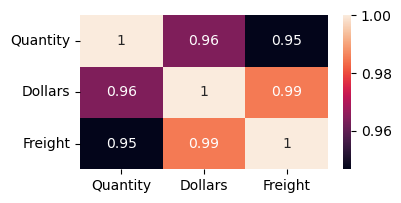

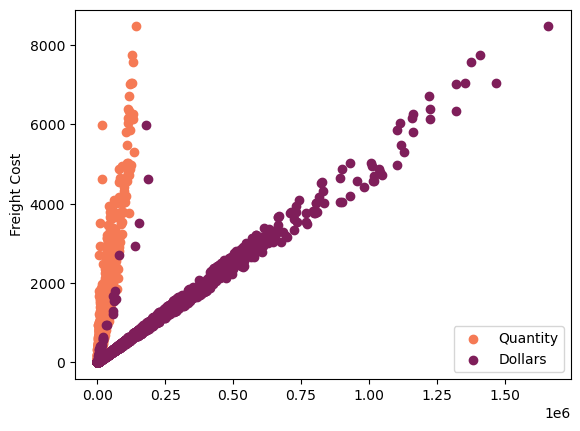

In [36]:
# Relationship between Quantity, Dollars and Freight

plt.figure(figsize=(4,2))
sns.heatmap(
    vendor_df[['Quantity', 'Dollars', 'Freight']].corr(),
    annot=True
)
plt.show()

plt.scatter(
    vendor_df['Quantity'],
    vendor_df['Freight'],
    color='#f57a55'
)

plt.scatter(
    vendor_df['Dollars'],
    vendor_df['Freight'],
    color='#7f1e5a'
)

plt.legend(['Quantity', 'Dollars'])
plt.ylabel('Freight Cost')
plt.show()

Feature Engineering
Derived Feature
Feature Creation

New Feature : freight_per_unit

In [37]:
vendor_df['freight_per_unit'] = (
    vendor_df['Freight'] / vendor_df['Quantity']
)

vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


Business Insight Discovery
Based on the above table we just discovered that :
    Large quantities: Lower Freight Per Unit
    Small quantities: Higher Freight Per Unit

In [38]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [39]:
low_quantity

np.float64(83.0)

25% of invoices have Quantity ≤ 83

In [40]:
high_quantity

np.float64(5100.5)

75% of invoices have Quantity ≤ 5100.5  
Top 25% invoices have Quantity > 5100.5

In [41]:
vendor_df.loc[
    vendor_df['Quantity'] < low_quantity,
    'freight_per_unit'
]

0       0.578333
1       0.571333
2       0.922000
5       0.100000
7       0.881667
          ...   
5523    0.102778
5526    0.088308
5527    0.048611
5528    0.032000
5537    0.053333
Name: freight_per_unit, Length: 1384, dtype: float64

In [42]:
vendor_df.loc[
    vendor_df['Quantity'] > high_quantity,
    'freight_per_unit'
]

3       0.290614
14      0.183063
18      0.359743
22      0.160885
32      0.301962
          ...   
5529    0.036190
5530    0.029653
5532    0.071002
5540    0.094735
5541    0.033117
Name: freight_per_unit, Length: 1386, dtype: float64

This segments invoices into low-volume and high-volume purchase groups using quantity quartiles and compared freight cost per unit across segments. This helped identify economies of scale in vendor procurement and shipping costs.

In [43]:
vendor_df.loc[
    vendor_df['Quantity'] < low_quantity,
    'freight_per_unit'
].mean()

np.float64(0.09489854253138316)

In [44]:
vendor_df.loc[
    vendor_df['Quantity'] > high_quantity,
    'freight_per_unit'
].mean()

np.float64(0.049077654690759046)

So we observed, buying in bulk nearly halves the shipping cost per item.
0.0949 / 0.0491 ≈ 1.93x

This is the economics of scale
This step is Hypothesis Testing (Business Hypothesis) 

Now we will doFeature Selection

In [45]:
X = vendor_df[['Quantity', 'Dollars']]
y = vendor_df['Freight']

In [46]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


Note : Our goal is to predict freight cost for ALL vendors.
        That includes:
        Small Vendors , 
        Medium Vendors , 
        Large Vendors , 
        Enterprise Vendors

        If we remove large vendors:

        Model becomes biased towards only small and medium orders.

        The points at the far right:

        Quantity/Dollars very high
        Freight very high

        are likely these outliers.

        But we notice something:
        They still follow the trend.

        The relationship is still:
        More Dollars  →  More Freight

        So these points are not random noise.

        They carry useful information.

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [49]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

model2 = DecisionTreeRegressor(max_depth = 4 , random_state=42)
model2.fit(X_train, y_train)

model3 = RandomForestRegressor(max_depth = 4, random_state=42)
model3.fit(X_train, y_train)

model4 = XGBRegressor(
    n_estimators=100, max_depth=4,
    learning_rate=0.1, random_state=42
)
model4.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [50]:
import numpy as np


def evaluate_model(model, X_test, y_test, model_name):

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds) * 100

    print(f"\n{model_name} Performance:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}%")

In [51]:
evaluate_model(model1, X_test, y_test, "Linear Regression")
evaluate_model(model2, X_test, y_test, "Decision Tree Regression")
evaluate_model(model3, X_test, y_test, "Random Forest Regression")
evaluate_model(model4, X_test, y_test, "XGBoost Regression")


Linear Regression Performance:
MAE  : 24.46
RMSE : 124.43
R²   : 97.00%

Decision Tree Regression Performance:
MAE  : 38.12
RMSE : 138.25
R²   : 96.30%

Random Forest Regression Performance:
MAE  : 30.27
RMSE : 130.63
R²   : 96.70%

XGBoost Regression Performance:
MAE  : 26.96
RMSE : 154.20
R²   : 95.40%


So we benchmarked Linear Regression, Decision Tree, Random Forest and XGBoost. Surprisingly, Linear Regression achieved the best performance because the underlying relationship between invoice value and freight cost was highly linear.

In [52]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(f"{grid_search.best_score_:.4f}")

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}

Best Cross Validation Score:
0.9612


The optimizer chose a very shallow tree of max_depth = 2 . This tell us that the relationship between Quantity/Dollars and Freight is fairly simple and does not require a very complex model.
This observation aligns with the strong performance of Linear Regression.

In [53]:
best_xgb = grid_search.best_estimator_

evaluate_model(
    best_xgb,
    X_test,
    y_test,
    "Tuned XGBoost"
)


Tuned XGBoost Performance:
MAE  : 26.34
RMSE : 150.52
R²   : 95.61%


## Model Selection Summary

Linear Regression, Decision Tree, Random Forest, XGBoost, and a GridSearchCV-tuned XGBoost model were evaluated.

GridSearchCV successfully improved XGBoost performance by optimizing hyperparameters such as max_depth, learning_rate, and n_estimators.

However, Linear Regression remained the strongest performer with the highest R² score and lowest prediction error. This indicates that freight cost exhibits a predominantly linear relationship with invoice value and quantity.

Therefore, Linear Regression was selected as the final model for deployment, while XGBoost and SHAP analysis were retained for model interpretability and comparative benchmarking.

# Actual vs Predicted Analysis

To validate the final Linear Regression model, actual freight costs were compared against model predictions on unseen test data.

The strong alignment of points along the diagonal reference line indicates that the model accurately captures the relationship between invoice characteristics and freight cost. Only a small number of observations deviate noticeably from the trend, suggesting the presence of unusual purchasing patterns or vendor-specific behavior.

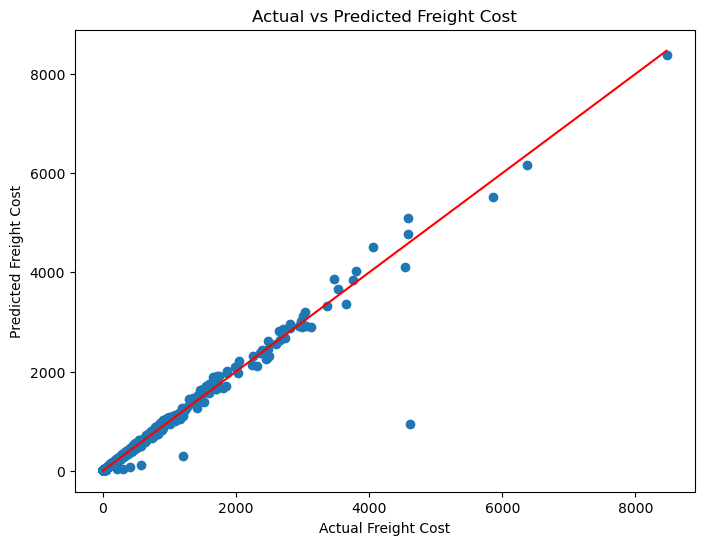

In [58]:
y_pred = model1.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Freight Cost")
plt.ylabel("Predicted Freight Cost")
plt.title("Actual vs Predicted Freight Cost")

plt.show()

In [54]:
import pandas as pd

importance = best_xgb.feature_importances_

pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

,Feature,Importance
1,Dollars,0.988739
0,Quantity,0.011261


# Feature Importance Analysis

XGBoost feature importance revealed that invoice dollar value accounted for approximately 99% of the model's predictive power, while quantity contributed roughly 1%.

This indicates that freight costs are primarily influenced by the monetary value of purchases. However, quantity was retained in the final feature set because it remains a meaningful business variable and may provide additional predictive signal for unseen data.

# Explainable AI using SHAP

SHAP (SHapley Additive exPlanations) was used to understand the contribution of each feature to model predictions and validate the feature importance results obtained from XGBoost.

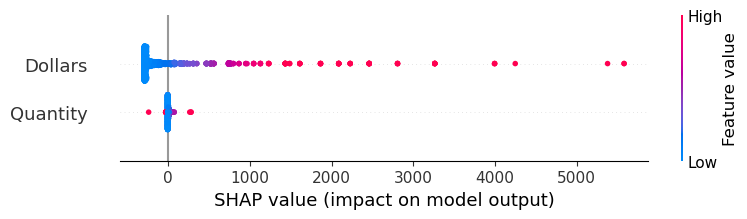

In [55]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

Here we are using SHAP (SHapley Additive Explanations) to analyze feature contributions. The SHAP summary plot confirmed that invoice dollar value was the dominant factor influencing freight cost predictions, while quantity had comparatively lower impact.

# Freight Cost Prediction for New Invoices

To demonstrate real-world applicability, the trained model was used to estimate freight costs for new hypothetical invoices.

This simulates how the solution could support procurement and logistics teams by forecasting shipping expenses before purchase orders are finalized.

In [59]:
input_data = {
    "Quantity":[500,200],
    "Dollars":[18500,9000]
}

df = pd.DataFrame(input_data)

model1.predict(df)

array([101.06889149,  52.13322816])

The final production model selected for inference was Linear Regression, as it achieved the highest R² score and lowest prediction error among all evaluated models.

# Final Project Conclusion

The objective of this project was to predict vendor freight costs using invoice-related features.

Key findings:

- Freight cost exhibited a strong positive relationship with invoice dollar value.
- Larger purchase quantities generally benefited from economies of scale, reducing freight cost per unit.
- Multiple machine learning models were benchmarked, including Linear Regression, Decision Tree, Random Forest, XGBoost, and a GridSearchCV-tuned XGBoost model.
- Linear Regression achieved the strongest overall performance with an R² score of approximately 97%.
- Feature importance analysis and SHAP explainability confirmed that invoice dollar value was the dominant driver of freight cost predictions.

This project demonstrates a complete machine learning workflow including data extraction, exploratory analysis, feature engineering, model development, hyperparameter optimization, model interpretability, and business insight generation.